In [1]:
from transformers import CLIPTokenizer
from transformers import CLIPProcessor
from transformers import CLIPModel
import torch
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL  import Image
import requests
from io import BytesIO

``` Load the model ```

In [2]:
#Defining the model name from clip variant (Vision=-Transformer-base-32x32 patch )
model_name="openai/clip-vit-base-patch32"
#Load pretrained CLIP model from Hugging Face
model=CLIPModel.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


```Tokenize the text string```

In [3]:
#Load tokenizer with specified clip model
tokenizer=CLIPTokenizer.from_pretrained(model_name)
#Text to preprocess and tokenize
text=["a donut", "a cookie", "an airplane", "a cat"]
#Tokenize and preprocess the text inputs
inputs=tokenizer(text,padding=True,return_tensors='pt')
#unpack the inputs
input_ids=inputs.input_ids # tokenized and text input
#Print information about unpack inputs
print("Input ids(shape):",input_ids.shape)
print(input_ids)

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Input ids(shape): torch.Size([4, 4])
tensor([[49406,   320, 18471, 49407],
        [49406,   320,  9367, 49407],
        [49406,   550, 16451, 49407],
        [49406,   320,  2368, 49407]])


```Find text embeddings```


CLIP model take in tokenize tring and return 512 length embedding for every string

In [4]:
# Compute text embeddings without computing gradient
with torch.no_grad():
  # Obtain text embeddings(feature vector) from CLIP model
  text_embedding=model.get_text_features(**inputs).pooler_output
#shape is no of text and embedding dimension
text_embedding.shape


torch.Size([4, 512])

```Calculate similarity matrix using cosine similarity```

Text(45.72222222222221, 0.5, 'Text Embeddings')

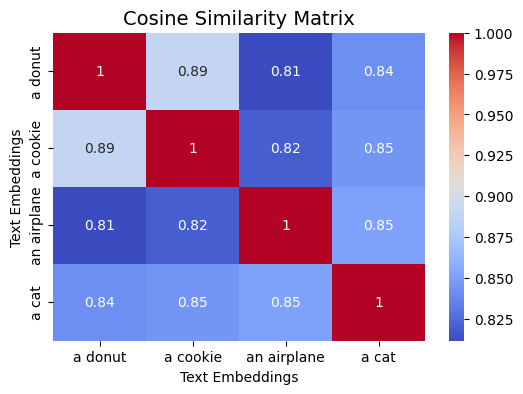

In [5]:
# Text Embedding is a shape of [n,d]
#n -- No of text prompts d -- embedding dimension
cosine_sim=F.cosine_similarity(
    text_embedding[:,None,:],
    text_embedding[None,:,:],
    dim=2
).cpu().numpy() # Move the values to cpu and convert into numpy tensor for plotting
plt.figure(figsize=(6,4)) #Initialize a matplotllib figure with specified size
sns.heatmap(
    cosine_sim,
    annot=True,
    cmap="coolwarm",
    xticklabels=text,
    yticklabels=text
)
#Set the plot title
plt.title("Cosine Similarity Matrix",fontsize=14)
plt.xlabel("Text Embeddings")
plt.ylabel("Text Embeddings")


``` Plot Images ```

In [17]:
def plot_images(images,labels):
  n=len(images)
  fig,axes=plt.subplots(1,n)
  for ax,img,lbl in zip(axes,images,labels):
    ax.imshow(img)
    ax.set_title(lbl)
    ax.axis("off")
  plt.tight_layout()
  plt.show()

``` Load and Diplay images ```

In [8]:
# Load pretrained CLIP processor to handle text-processing and images
processor=CLIPProcessor.from_pretrained(model_name)

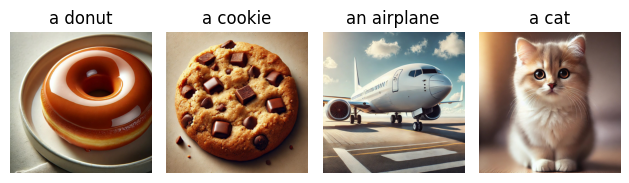

In [18]:
# Dictionary containing images and urls
image_urls={
    "a donut":  "https://learnopencv.com/wp-content/uploads/2025/03/donut.jpeg",
    "a cookie": "https://learnopencv.com/wp-content/uploads/2025/03/cookie.jpeg",
    "an airplane": "https://learnopencv.com/wp-content/uploads/2025/03/airplane.jpeg",
    "a cat": "https://learnopencv.com/wp-content/uploads/2025/03/cat.jpeg"
}
labels=list(image_urls.keys())
def load_images(url):
  headers={'User_Agents':'Mozilla/5.0'}
  response=requests.get(url,headers=headers)
  response.raise_for_status()
  return Image.open(BytesIO(response.content)).convert('RGB')
#Initialise Empty list
images=[]
for label in labels:
  image=load_images(image_urls[label])
  images.append(image)

#Display loaded images
plot_images(images,labels)

``` Calculating Image embeddings and display similarity```

torch.Size([4, 512])


Text(45.72222222222221, 0.5, 'Text Embeddings')

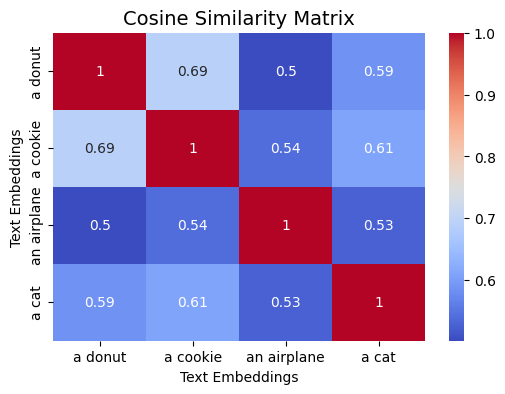

In [24]:
image_inputs=processor(images=images,return_tensors="pt")
# Compute image embeddings without computing gradient
with torch.no_grad():
  # Obtain image embeddings(feature vector) from CLIP model
  image_embedding=model.get_image_features(**image_inputs).pooler_output
#shape is no of text and embedding dimension
print(image_embedding.shape)
cosine_sim=F.cosine_similarity(
    image_embedding[:,None,:],
    image_embedding[None,:,:],
    dim=2
).cpu().numpy() # Move the values to cpu and convert into numpy tensor for plotting
plt.figure(figsize=(6,4)) #Initialize a matplotllib figure with specified size
sns.heatmap(
    cosine_sim,
    annot=True,
    cmap="coolwarm",
    xticklabels=text,
    yticklabels=text
)
#Set the plot title
plt.title("Cosine Similarity Matrix",fontsize=14)
plt.xlabel("Image Embeddings")
plt.ylabel("Image Embeddings")


``` Calculate imge-text similarity```

Text(45.72222222222221, 0.5, 'Image Embeddings')

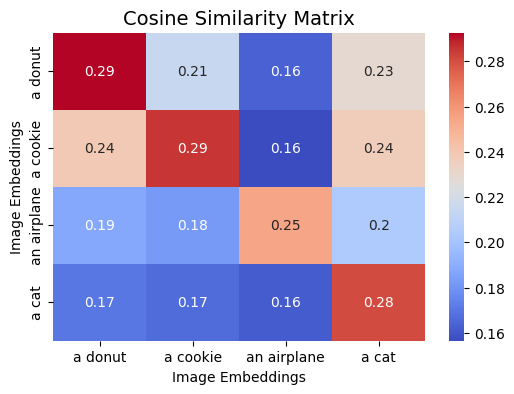

In [25]:
text_image_similarity=F.cosine_similarity(
    text_embedding[:,None,:],
    image_embedding[None,:,:],
    dim=2
).cpu().numpy()
plt.figure(figsize=(6,4)) #Initialize a matplotllib figure with specified size
sns.heatmap(
    text_image_similarity,
    annot=True,
    cmap="coolwarm",
    xticklabels=text,
    yticklabels=text
)
#Set the plot title
plt.title("Cosine Similarity Matrix",fontsize=14)
plt.xlabel("Image Embeddings")
plt.ylabel("Image Embeddings")
